In [13]:
import boto3
import pandas as pd
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

In [2]:
s3 = boto3.resource('s3')

source_bucket = s3.Bucket(name="dsan6000-em1569")

summaries = list(source_bucket.objects.filter(Prefix="wikipedia-hourly"))

In [3]:
objects = [s.Object() for s in summaries]

In [4]:
dfs = []
target_row_count = 0

for obj in objects:
    hour_df = pd.read_parquet(f"s3://dsan6000-em1569/{obj.key}")
    target_row_count += len(hour_df)
    dfs.append(hour_df)

df = pd.concat(dfs)
print(target_row_count)

119708


In [5]:
len(df)

119708

In [6]:
df.datetime = pd.to_datetime(df.datetime)
df['hour']= df.datetime.dt.hour

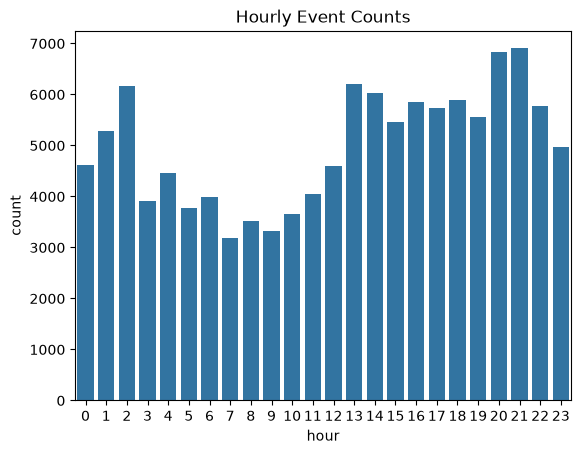

In [16]:
hourly_plot = sns.countplot(df, x=df['hour']).set_title('Hourly Event Counts')
fig = hourly_plot.get_figure()
fig.savefig("images/hourly-events.png")
fig.savefig("images/hourly-events.svg")

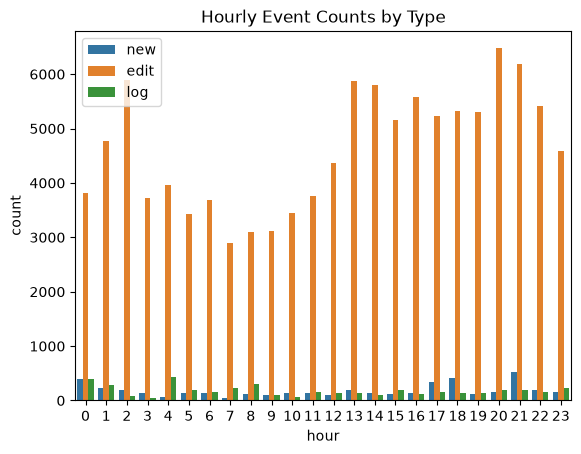

In [18]:
type_plot = sns.countplot(df, x=df['hour'],hue='type').set_title('Hourly Event Counts by Type')
plt.legend()
type_fig = type_plot.get_figure()
type_fig.savefig("images/events-by-type.png")
type_fig.savefig("images/events-by-type.svg")